# Annotation Notebook

In [1]:
from eval.annotation import draw_segments, save_ground_truth
from app.services.image_processing import read_image

import matplotlib.pyplot as plt
import numpy as np

<Figure size 800x800 with 0 Axes>

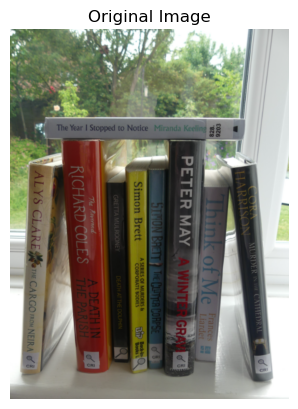

In [2]:
img = read_image("images/bookshelf3.png", max_dim=1024)

plt.figure(figsize=(8, 8))
fig, ax = plt.subplots()
ax.axis("off")
ax.set_title("Original Image")
ax.imshow(img)
plt.show()

Image shape is (797, 601, 3)


<Figure size 800x800 with 0 Axes>

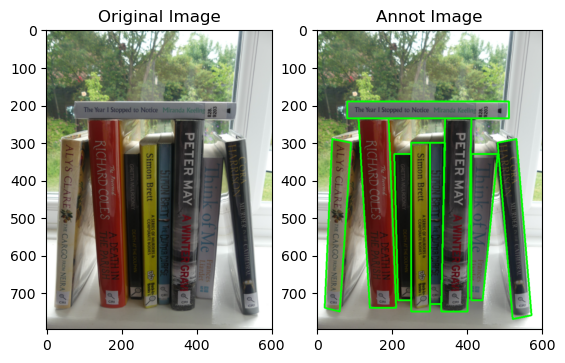

In [3]:
polygons = [
    [[80, 190], [510, 190], [510, 235], [80, 235]],
    [[40, 290], [90, 300], [60, 750], [20, 740]],
    [[110, 235], [190, 235], [210, 740], [140, 740]],
    [[205, 330], [250, 330], [250, 720], [215, 720]],
    [[250, 300], [300, 300], [300, 750], [250, 750]],
    [[300, 300], [340, 300], [330, 730], [300, 730]],
    [[340, 235], [410, 235], [400, 750], [330, 750]],
    [[410, 330], [480, 330], [440, 720], [410, 720]],
    [[480, 300], [530, 290], [570, 760], [520, 770]],
]

annot_img = draw_segments(
    img,
    polygons,
)

print(f"Image shape is {img.shape}")

plt.figure(figsize=(8,8))
fig, ax = plt.subplots(1, 2)
ax[0].set_title("Original Image")
ax[0].imshow(img)
ax[1].set_title("Annot Image")
ax[1].imshow(annot_img)
plt.show()

In [ ]:
polygons = [
    [[80, 190], [510, 190], [510, 235], [80, 235]],
    [[40, 290], [90, 300], [60, 750], [20, 740]],
    [[110, 235], [190, 235], [210, 740], [140, 740]],
    [[205, 330], [250, 330], [250, 720], [215, 720]],
    [[250, 300], [300, 300], [300, 750], [250, 750]],
    [[300, 300], [340, 300], [330, 730], [300, 730]],
    [[340, 235], [410, 235], [400, 750], [330, 750]],
    [[410, 330], [480, 330], [440, 720], [410, 720]],
    [[480, 300], [530, 290], [570, 760], [520, 770]],
]

annot_img = draw_segments(
    img,
    polygons,
)

print(f"Image shape is {img.shape}")

plt.figure(figsize=(8,8))
fig, ax = plt.subplots(1, 2)
ax[0].set_title("Original Image")
ax[0].imshow(img)
ax[1].set_title("Annot Image")
ax[1].imshow(annot_img)
plt.show()

In [57]:
save_ground_truth(img, polygons)

('images/eval/test_img_0.png', 'images/eval/ground_truth.json')

## Eval

In [4]:
from eval.segmentation import variation_of_information, mutual_information, evaluate_segmentation, compare_segmentations, visualize_mean_colours
from app.services.image_processing import SimpleSegmenter, thd_split_mask_variation

In [5]:
segmenter = SimpleSegmenter()

In [ ]:
def tree_segmentation(img):
    segmenter.load(img, max_dim=1e6)
    segments = segmenter.segment()

    image_height, image_width = img.shape[:2]

    masks = []
    
    for i, (x1, y1, x2, y2) in enumerate(segments):
        mask = np.zeros((image_height, image_width), dtype=np.uint8)
        # Clip coordinates to image bounds (important)
        x1c = max(0, min(image_width, x1))
        x2c = max(0, min(image_width, x2))
        y1c = max(0, min(image_height, y1))
        y2c = max(0, min(image_height, y2))

        # Create the binary region in the mask
        mask[y1c:y2c, x1c:x2c] = 1

        masks.append(mask)
    return masks

import cv2

def tree_segmentation_2(img):
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    l = clahe.apply(l)
    lab = cv2.merge([l, a, b])
    img_standard = cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)

    # run tree segmentation
    leaves, split_lines = thd_split_mask_variation(img_standard, None, depth=0, max_depth=8,
                                min_pixels=int(img.shape[0]*img.shape[0]*0.01), min_side_fraction=0.3, pad=5,
                                min_child_ratio=0.2, min_score=0.01,
                                n_hough_lines=10, lines_so_far=None,
                                max_aspect_ratio=10,
                                blur=True, blur_ksize=(9,9), blur_sigma=3, ignore_min_score=20)
    
    return leaves

Now have 2 segments
Now have 4 segments
Now have 6 segments
Now have 8 segments
Now have 10 segments
Now have 12 segments
Now have 15 segments
Now have 18 segments
Now have 21 segments
Now have 24 segments
Now have 26 segments
Now have 28 segments
Now have 30 segments
Now have 32 segments
Now have 34 segments
Now have 36 segments
Now have 37 segments
Now have 38 segments
Now have 39 segments
Now have 39 segments

Found 39 leaf segments.
Depth 0 | Segments 1: best score=0.364, child ratios=0.10, 0.90
Depth 1 | Segments 2: best score=0.031, child ratios=0.23, 0.77
Depth 2 | Segments 3: best score=0.102, child ratios=0.24, 0.76
Depth 3 | Segments 4: best score=0.052, child ratios=0.70, 0.30
Depth 3 | Segments 5: best score=0.019, child ratios=0.32, 0.68
Depth 2 | Segments 6: best score=0.064, child ratios=0.53, 0.47
Depth 3 | Segments 7: best score=0.088, child ratios=0.70, 0.30
Depth 4 | Segments 8: best score=0.192, child ratios=0.08, 0.92
Depth 5 | Segments 9: best score=0.057, child r

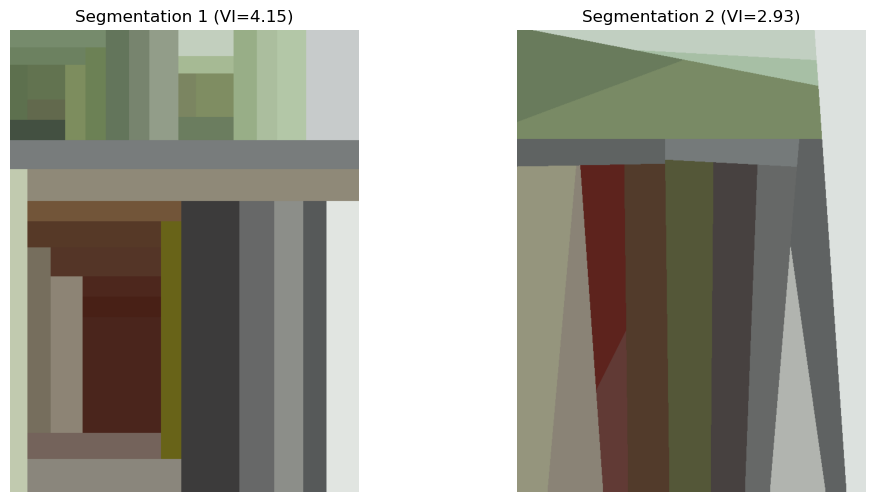

In [11]:
compare_segmentations("images/eval", segmentation_function1=tree_segmentation, segmentation_function2=tree_segmentation_2, image_index=0)

In [7]:
evaluate_segmentation("images/eval", tree_segmentation)

Now have 2 segments
Now have 4 segments
Now have 6 segments
Now have 8 segments
Now have 10 segments
Now have 12 segments
Now have 15 segments
Now have 18 segments
Now have 21 segments
Now have 24 segments
Now have 27 segments
Now have 29 segments
Now have 31 segments
Now have 33 segments
Now have 35 segments
Now have 37 segments
Now have 38 segments
Now have 39 segments
Now have 40 segments
Now have 41 segments
Now have 42 segments
Now have 43 segments
Now have 44 segments
Now have 45 segments
Now have 45 segments

Found 45 leaf segments.
test_img_0.png: VI = 4.2283


[('test_img_0.png', np.float64(4.228320300457872))]

In [9]:
evaluate_segmentation("images/eval", tree_segmentation_2)

Depth 0 | Segments 1: best score=0.359, child ratios=0.10, 0.90
Depth 1 | Segments 2: best score=0.032, child ratios=0.23, 0.77
Depth 2 | Segments 3: best score=0.162, child ratios=0.20, 0.80
Depth 3 | Segments 4: best score=0.026, child ratios=0.30, 0.70
Depth 2 | Segments 5: best score=0.066, child ratios=0.54, 0.46
Depth 3 | Segments 6: best score=0.304, child ratios=0.07, 0.93
Depth 4 | Segments 7: best score=0.044, child ratios=0.57, 0.43
Depth 5 | Segments 8: best score=0.161, child ratios=0.60, 0.40
Depth 6 | Segments 9: best score=0.001, child ratios=0.65, 0.35
Depth 5 | Segments 10: best score=0.057, child ratios=0.61, 0.39
Depth 3 | Segments 11: best score=0.120, child ratios=0.66, 0.34
Depth 4 | Segments 12: best score=0.205, child ratios=0.08, 0.92
Depth 5 | Segments 13: best score=0.113, child ratios=0.65, 0.35
Depth 4 | Segments 14: best score=0.187, child ratios=0.62, 0.38
Total non-empty segments: 15
test_img_0.png: VI = 2.8942


[('test_img_0.png', np.float64(2.894197719364311))]

<Figure size 800x800 with 0 Axes>

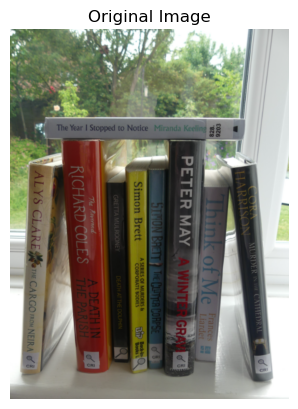

Now have 2 segments
Now have 4 segments
Now have 6 segments
Now have 8 segments
Now have 10 segments
Now have 12 segments
Now have 15 segments
Now have 18 segments
Now have 21 segments
Now have 24 segments
Now have 27 segments
Now have 29 segments
Now have 31 segments
Now have 33 segments
Now have 35 segments
Now have 37 segments
Now have 38 segments
Now have 39 segments
Now have 40 segments
Now have 41 segments
Now have 42 segments
Now have 43 segments
Now have 44 segments
Now have 45 segments
Now have 45 segments

Found 45 leaf segments.


<Figure size 800x800 with 0 Axes>

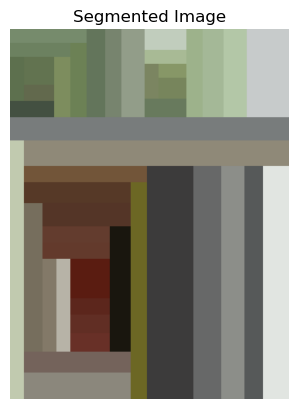

In [304]:
from app.services.image_processing import read_image, mean_value_spine_image

# Choose image
image_path = "images/bookshelf3.png"

# Read and display
img = read_image(image_path, max_dim=1024)

plt.figure(figsize=(8, 8))
fig, ax = plt.subplots()
ax.axis("off")
ax.set_title("Original Image")
ax.imshow(img)
plt.show()

book_spines = segmenter.segment()

# Recreate image with segments to flatten colours by segment
img_segmented = mean_value_spine_image(img, book_spines)

# Display segmented image
plt.figure(figsize=(8, 8))
fig, ax = plt.subplots()
ax.axis("off")
ax.set_title("Segmented Image")
ax.imshow(img_segmented)
plt.show()

# plt.savefig(
#     "images/bookshelf3_segmented.png",
#     bbox_inches="tight",
#     pad_inches=0
# )

Depth 0 | Segments 1: best score=0.075, child ratios=0.92, 0.08
Depth 1 | Segments 2: best score=0.068, child ratios=0.91, 0.09
Depth 2 | Segments 3: best score=0.050, child ratios=0.60, 0.40
Depth 3 | Segments 4: best score=0.046, child ratios=0.54, 0.46
Depth 4 | Segments 5: best score=0.076, child ratios=0.91, 0.09
Depth 5 | Segments 6: best score=0.046, child ratios=0.27, 0.73
Depth 6 | Segments 7: best score=0.099, child ratios=0.50, 0.50
Depth 6 | Segments 8: best score=0.317, child ratios=0.24, 0.76
Depth 7 | Segments 9: best score=0.040, child ratios=0.47, 0.53
Depth 4 | Segments 10: best score=0.247, child ratios=0.24, 0.76
Depth 5 | Segments 11: best score=0.115, child ratios=0.12, 0.88
Depth 6 | Segments 12: best score=0.111, child ratios=0.17, 0.83
Depth 7 | Segments 13: best score=0.119, child ratios=0.36, 0.64
Depth 3 | Segments 14: best score=0.081, child ratios=0.90, 0.10
Depth 4 | Segments 15: best score=0.081, child ratios=0.27, 0.73
Depth 5 | Segments 16: best score=

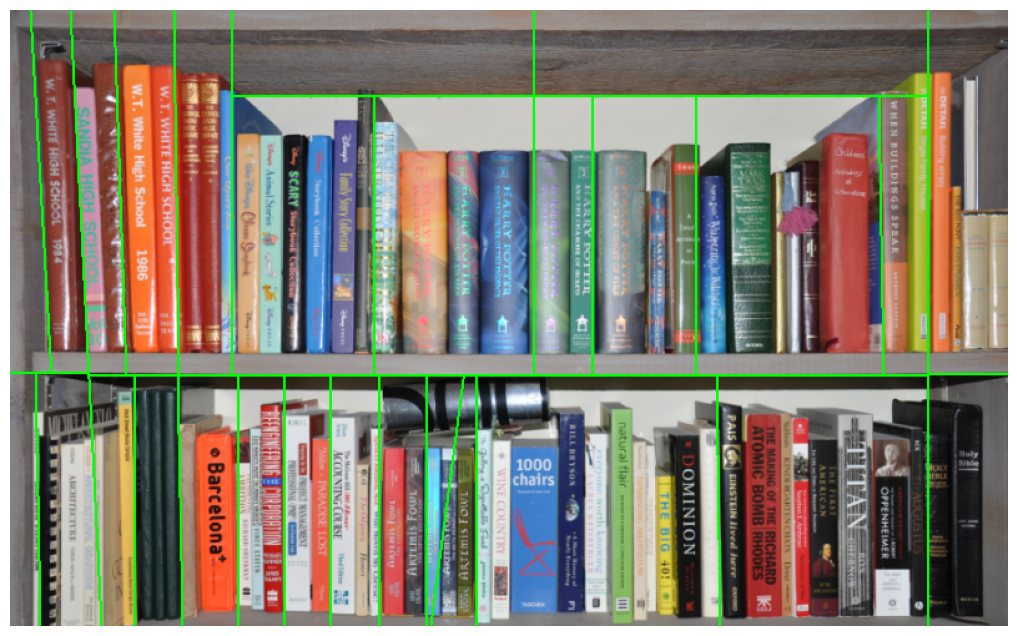

Total segments: 28


In [299]:
img = cv2.imread("images/bookshelf2.png")

target_width = 800
scale = target_width / img.shape[1]
img = cv2.resize(img, (target_width, int(img.shape[0]*scale)))

lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
l, a, b = cv2.split(lab)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
l = clahe.apply(l)
lab = cv2.merge([l, a, b])
img_standard = cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)

# run tree segmentation
leaves, split_lines = thd_split_mask_variation(img_standard, None, depth=0, max_depth=8,
                             min_pixels=int(img.shape[0]*img.shape[0]*0.01), min_side_fraction=0.3, pad=5,
                             min_child_ratio=0.2, min_score=0.01,
                             n_hough_lines=10, lines_so_far=None,
                             max_aspect_ratio=10,
                             blur=True, blur_ksize=(9,9), blur_sigma=3, ignore_min_score=20)


# visualize boundaries
visualize_segment_boundaries(img, leaves)

print(f"Total segments: {len(leaves)}")